<a href="https://colab.research.google.com/github/lavanyan1105-afk/Brain-Tumor-/blob/main/Brain_tuomer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

### Tumor Type Counts

In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Define classes and their labels
classes = {'no_tumor': 0, 'pituitary_tumor': 1, 'glioma_tumor': 2, 'meningioma_tumor': 3}

# Load and preprocess the dataset
X = []
Y = []
for cls_name, label in classes.items():
    class_pth = f"/content/drive/MyDrive/Brain_Tumer/Training/{cls_name}" # Correct path for each class
    for filename in os.listdir(class_pth):
        img_path = os.path.join(class_pth, filename)
        img = cv2.imread(img_path, 0)
        if img is not None: # Check if image was loaded successfully
            img = cv2.resize(img, (200, 200))
            X.append(img.flatten() / 255.0)  # Flatten and normalize the image data
            Y.append(label)
        else:
            print(f"Warning: Could not load image {img_path}") # Optional: print a warning
X = np.array(X)
Y = np.array(Y)

In [ ]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, random_state=10, test_size=0.2)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train Support Vector Classifier
sv = SVC()
sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)
print("Training Score:", train_score)
print("Testing Score:", test_score)

Training Score: 0.9677700348432056
Testing Score: 0.8362369337979094


### Distribution of Tumor Types Histogram

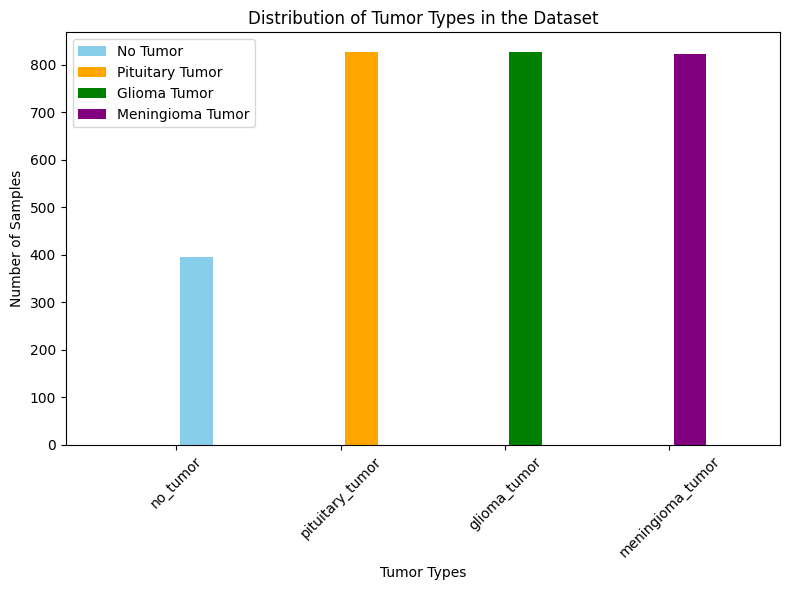

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define class labels (moved from a later cell to resolve NameError)
dec = {0: 'No Tumor', 1: 'Pituitary Tumor', 2: 'Glioma Tumor', 3: 'Meningioma Tumor'}

# Create a histogram of tumor types with different colors
tumor_labels = [dec[label] for label in Y]
colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8, 6))
for label, color in zip(classes.values(), colors):
    plt.hist(np.array(tumor_labels)[Y == label], bins=len(classes), align='mid', rwidth=0.8, color=color, label=dec[label])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')
plt.xticks(range(len(classes)), list(classes.keys()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Task
The task is complete.

### Evaluation of Training Data Size Impact

In [ ]:
from sklearn.model_selection import train_test_split

training_sizes = [0.2, 0.4, 0.6, 0.8]
linear_accuracies = []
rbf_accuracies = []

for size in training_sizes:
    # Split the original training data into a smaller subset
    xtrain_subset, _, ytrain_subset, _ = train_test_split(pca_train, ytrain, train_size=size, random_state=42, stratify=ytrain)

    # Train Linear Kernel SVC
    sv_linear_subset = SVC(kernel='linear')
    sv_linear_subset.fit(xtrain_subset, ytrain_subset)
    linear_accuracies.append(sv_linear_subset.score(pca_test, ytest))

    # Train RBF Kernel SVC
    sv_rbf_subset = SVC(kernel='rbf')
    sv_rbf_subset.fit(xtrain_subset, ytrain_subset)
    rbf_accuracies.append(sv_rbf_subset.score(pca_test, ytest))

print("Linear Kernel Accuracies for different training sizes:", linear_accuracies)
print("RBF Kernel Accuracies for different training sizes:", rbf_accuracies)

Linear Kernel Accuracies for different training sizes: [0.705574912891986, 0.7491289198606271, 0.7560975609756098, 0.7665505226480837]
RBF Kernel Accuracies for different training sizes: [0.7160278745644599, 0.7665505226480837, 0.7909407665505227, 0.8170731707317073]


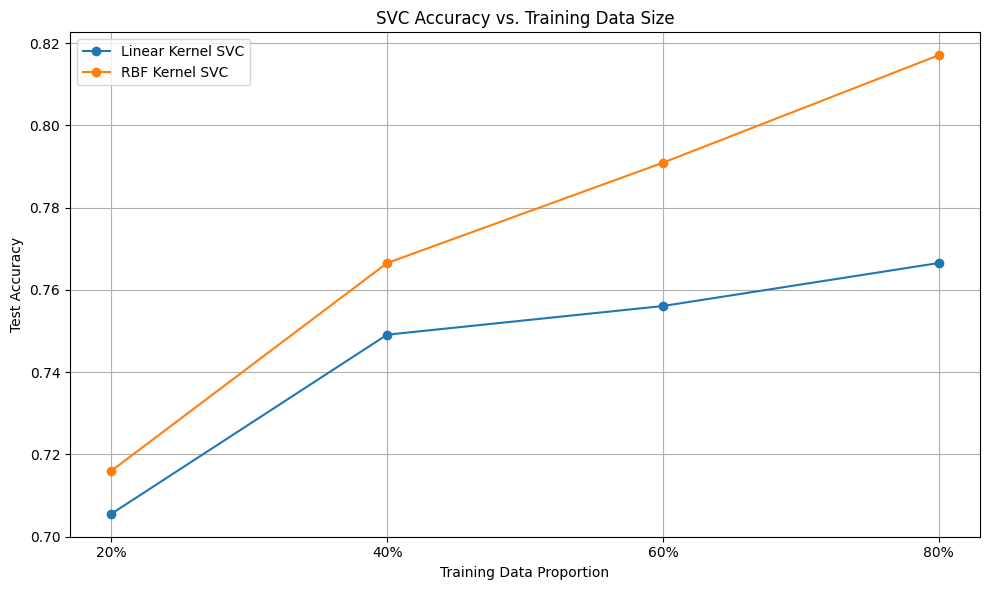

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(training_sizes, linear_accuracies, marker='o', label='Linear Kernel SVC')
plt.plot(training_sizes, rbf_accuracies, marker='o', label='RBF Kernel SVC')
plt.title('SVC Accuracy vs. Training Data Size')
plt.xlabel('Training Data Proportion')
plt.ylabel('Test Accuracy')
plt.xticks(training_sizes, [f'{int(s*100)}%' for s in training_sizes])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

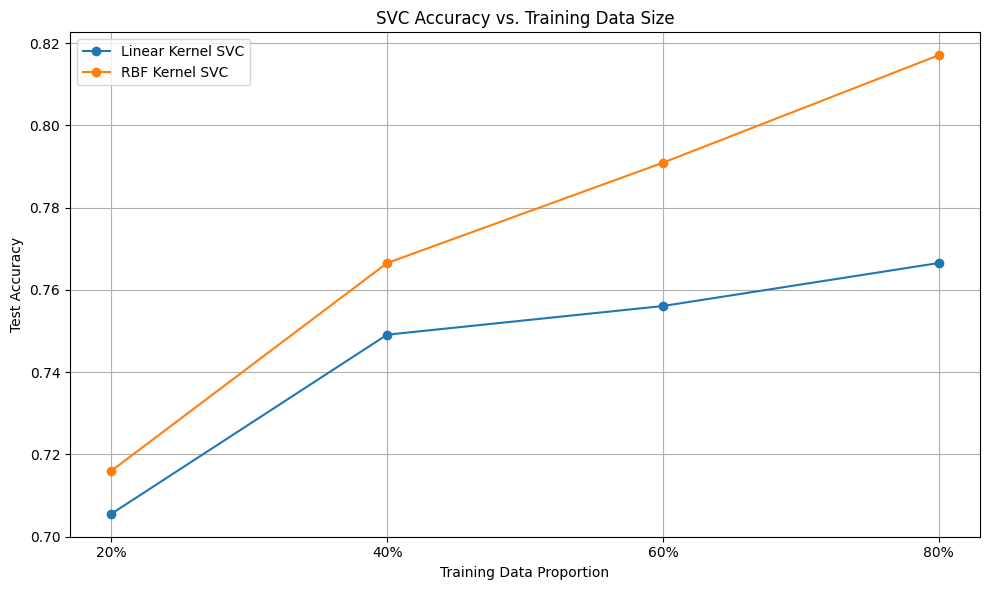

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(training_sizes, linear_accuracies, marker='o', label='Linear Kernel SVC')
plt.plot(training_sizes, rbf_accuracies, marker='o', label='RBF Kernel SVC')
plt.title('SVC Accuracy vs. Training Data Size')
plt.xlabel('Training Data Proportion')
plt.ylabel('Test Accuracy')
plt.xticks(training_sizes, [f'{int(s*100)}%' for s in training_sizes])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Evaluation of Training Data Size Impact

In [ ]:
print("Linear Kernel Accuracies for different training sizes:", linear_accuracies)
print("RBF Kernel Accuracies for different training sizes:", rbf_accuracies)

Linear Kernel Accuracies for different training sizes: [0.705574912891986, 0.7491289198606271, 0.7560975609756098, 0.7665505226480837]
RBF Kernel Accuracies for different training sizes: [0.7160278745644599, 0.7665505226480837, 0.7909407665505227, 0.8170731707317073]


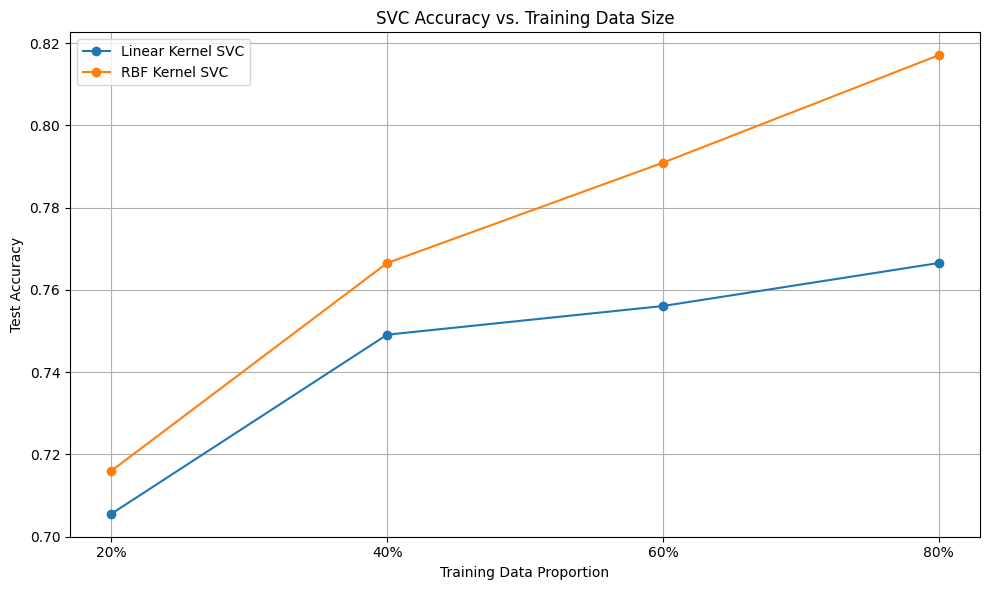

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(training_sizes, linear_accuracies, marker='o', label='Linear Kernel SVC')
plt.plot(training_sizes, rbf_accuracies, marker='o', label='RBF Kernel SVC')
plt.title('SVC Accuracy vs. Training Data Size')
plt.xlabel('Training Data Proportion')
plt.ylabel('Test Accuracy')
plt.xticks(training_sizes, [f'{int(s*100)}%' for s in training_sizes])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Comparison of SVM Kernel Performance

In [ ]:
from sklearn.svm import SVC

# Instantiate a new Support Vector Classifier (SVC) with a linear kernel
sv_linear = SVC(kernel='linear')

# Train the sv_linear model
sv_linear.fit(pca_train, ytrain)

# Evaluate the sv_linear model's performance on the test data
test_score_linear = sv_linear.score(pca_test, ytest)
print("Test Score with Linear Kernel SVC:", test_score_linear)

Test Score with Linear Kernel SVC: 0.7926829268292683


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

# Make predictions on the test set with the linear kernel SVC
y_pred_linear = sv_linear.predict(pca_test)

# Calculate accuracy
accuracy_linear = accuracy_score(ytest, y_pred_linear)

# Calculate F1-score (macro average for multiclass)
f1_linear = f1_score(ytest, y_pred_linear, average='macro')

# Calculate sensitivity (recall) (macro average for multiclass)
recall_linear = recall_score(ytest, y_pred_linear, average='macro')

# Calculate specificity for each class and then average them
# Specificity = TN / (TN + FP)
cm_linear = confusion_matrix(ytest, y_pred_linear)
specificity_per_class = []
for i in range(len(classes)):
    # True Negative (TN): sum of all cells not in the current row or column
    tn = np.sum(np.delete(np.delete(cm_linear, i, axis=0), i, axis=1))
    # False Positive (FP): sum of the current column (excluding the diagonal)
    fp = np.sum(cm_linear[:, i]) - cm_linear[i, i]
    specificity_per_class.append(tn / (tn + fp))
specificity_linear = np.mean(specificity_per_class)

print(f"Linear Kernel SVC Metrics:")
print(f"  Accuracy: {accuracy_linear:.4f}")
print(f"  F1-Score: {f1_linear:.4f}")
print(f"  Sensitivity (Recall): {recall_linear:.4f}")
print(f"  Specificity: {specificity_linear:.4f}")

Linear Kernel SVC Metrics:
  Accuracy: 0.7927
  F1-Score: 0.7799
  Sensitivity (Recall): 0.7780
  Specificity: 0.9294


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

# Instantiate a new Support Vector Classifier (SVC) with an RBF kernel
sv_rbf = SVC(kernel='rbf')

# Train the sv_rbf model
sv_rbf.fit(pca_train, ytrain)

# Make predictions on the test set with the RBF kernel SVC
y_pred_rbf = sv_rbf.predict(pca_test)

# Calculate accuracy
accuracy_rbf = accuracy_score(ytest, y_pred_rbf)

# Calculate F1-score (macro average for multiclass)
f1_rbf = f1_score(ytest, y_pred_rbf, average='macro')

# Calculate sensitivity (recall) (macro average for multiclass)
recall_rbf = recall_score(ytest, y_pred_rbf, average='macro')

# Calculate specificity for each class and then average them
cm_rbf = confusion_matrix(ytest, y_pred_rbf)
specificity_per_class_rbf = []
for i in range(len(classes)):
    tn_rbf = np.sum(np.delete(np.delete(cm_rbf, i, axis=0), i, axis=1))
    fp_rbf = np.sum(cm_rbf[:, i]) - cm_rbf[i, i]
    specificity_per_class_rbf.append(tn_rbf / (tn_rbf + fp_rbf))
specificity_rbf = np.mean(specificity_per_class_rbf)

print(f"RBF Kernel SVC Metrics:")
print(f"  Accuracy: {accuracy_rbf:.4f}")
print(f"  F1-Score: {f1_rbf:.4f}")
print(f"  Sensitivity (Recall): {recall_rbf:.4f}")
print(f"  Specificity: {specificity_rbf:.4f}")

RBF Kernel SVC Metrics:
  Accuracy: 0.8362
  F1-Score: 0.8316
  Sensitivity (Recall): 0.8339
  Specificity: 0.9447


In [ ]:
import pandas as pd

# Create a dictionary to store the metrics for comparison
metrics_data = {
    'Metric': ['Accuracy', 'F1-Score', 'Sensitivity (Recall)', 'Specificity'],
    'Linear Kernel': [accuracy_linear, f1_linear, recall_linear, specificity_linear],
    'RBF Kernel': [accuracy_rbf, f1_rbf, recall_rbf, specificity_rbf]
}

# Create a DataFrame for better visualization
performance_df = pd.DataFrame(metrics_data)

# Display the comparison table
print("\033[1mComparison of SVC Performance (Linear vs. RBF Kernel):\033[0m")
display(performance_df.style.set_properties(**{'border': '1px solid black', 'text-align': 'center'}))

Comparison of SVC Performance (Linear vs. RBF Kernel):


,Metric,Linear Kernel,RBF Kernel
0,Accuracy,0.792683,0.836237
1,F1-Score,0.779939,0.831580
2,Sensitivity (Recall),0.778006,0.833930
3,Specificity,0.929373,0.944655


In [ ]:
display(performance_df)

,Metric,Linear Kernel,RBF Kernel
0,Accuracy,0.792683,0.836237
1,F1-Score,0.779939,0.831580
2,Sensitivity (Recall),0.778006,0.833930
3,Specificity,0.929373,0.944655


In [ ]:
import pandas as pd

# Create a dictionary to store the metrics for comparison
metrics_data = {
    'Metric': ['Accuracy', 'F1-Score', 'Sensitivity (Recall)', 'Specificity'],
    'Linear Kernel': [accuracy_linear, f1_linear, recall_linear, specificity_linear],
    'RBF Kernel': [accuracy_rbf, f1_rbf, recall_rbf, specificity_rbf]
}

# Create a DataFrame for better visualization
performance_df = pd.DataFrame(metrics_data)

# Display the comparison table
print("\033[1mComparison of SVC Performance (Linear vs. RBF Kernel):\033[0m")
display(performance_df.style.set_properties(**{'border': '1px solid black', 'text-align': 'center'}))

Comparison of SVC Performance (Linear vs. RBF Kernel):


,Metric,Linear Kernel,RBF Kernel
0,Accuracy,0.792683,0.836237
1,F1-Score,0.779939,0.831580
2,Sensitivity (Recall),0.778006,0.833930
3,Specificity,0.929373,0.944655


In [ ]:
display(performance_df)

,Metric,Linear Kernel,RBF Kernel
0,Accuracy,0.792683,0.836237
1,F1-Score,0.779939,0.831580
2,Sensitivity (Recall),0.778006,0.833930
3,Specificity,0.929373,0.944655


In [ ]:
# Define classes and their labels
classes = {'no_tumor': 0, 'pituitary_tumor': 1, 'glioma_tumor': 2, 'meningioma_tumor': 3}

# Load and preprocess the dataset
X = []
Y = []
for cls_name, label in classes.items():
    class_pth = f"/content/drive/MyDrive/Brain_Tumer/Training/{cls_name}" # Correct path for each class
    for filename in os.listdir(class_pth):
        img_path = os.path.join(class_pth, filename)
        img = cv2.imread(img_path, 0)
        if img is not None: # Check if image was loaded successfully
            img = cv2.resize(img, (200, 200))
            X.append(img.flatten() / 255.0)  # Flatten and normalize the image data
            Y.append(label)
        else:
            print(f"Warning: Could not load image {img_path}") # Optional: print a warning
X = np.array(X)
Y = np.array(Y)

In [ ]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, random_state=10, test_size=0.2)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train Support Vector Classifier
sv = SVC()
sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)
print("Training Score:", train_score)
print("Testing Score:", test_score)

Training Score: 0.9677700348432056
Testing Score: 0.8362369337979094


In [ ]:
# Display sample images and predictions
def display_samples(folder, title, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for i, filename in enumerate(os.listdir(folder)[:num_samples]):
        img = cv2.imread(os.path.join(folder, filename), 0)
        img = cv2.resize(img, (200, 200)).flatten() / 255.0  # Preprocess the test image
        prediction = sv.predict(pca.transform([img]))  # Predict using the trained SVM

        plt.subplot(3, 3, c)
        plt.title(dec[prediction[0]])  # Map prediction to human-readable label
        plt.imshow(img.reshape(200, 200), cmap='gray')  # Display the image
        plt.axis('off')
        c += 1
    plt.suptitle(title)
    plt.show()

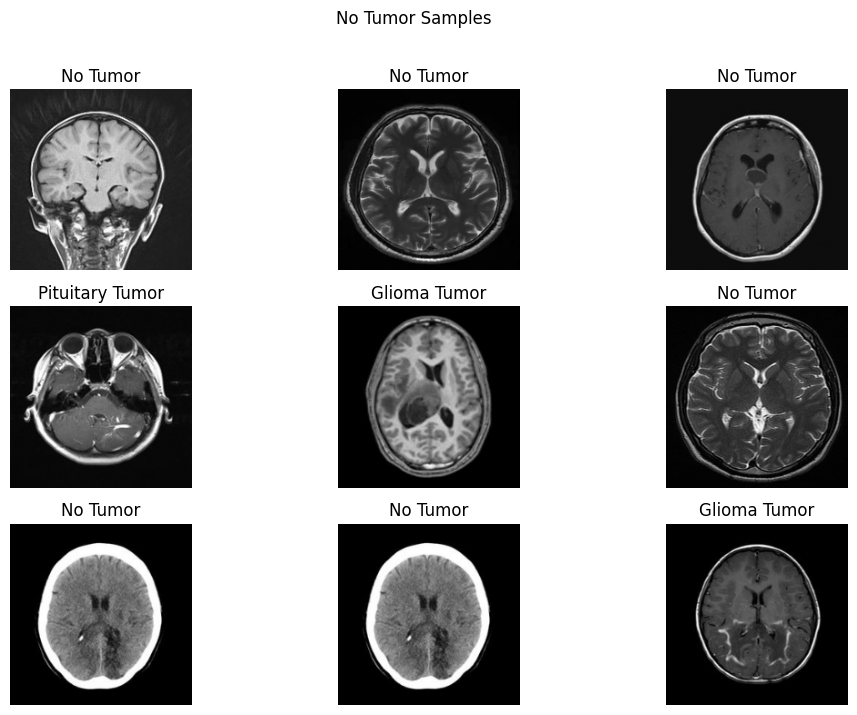

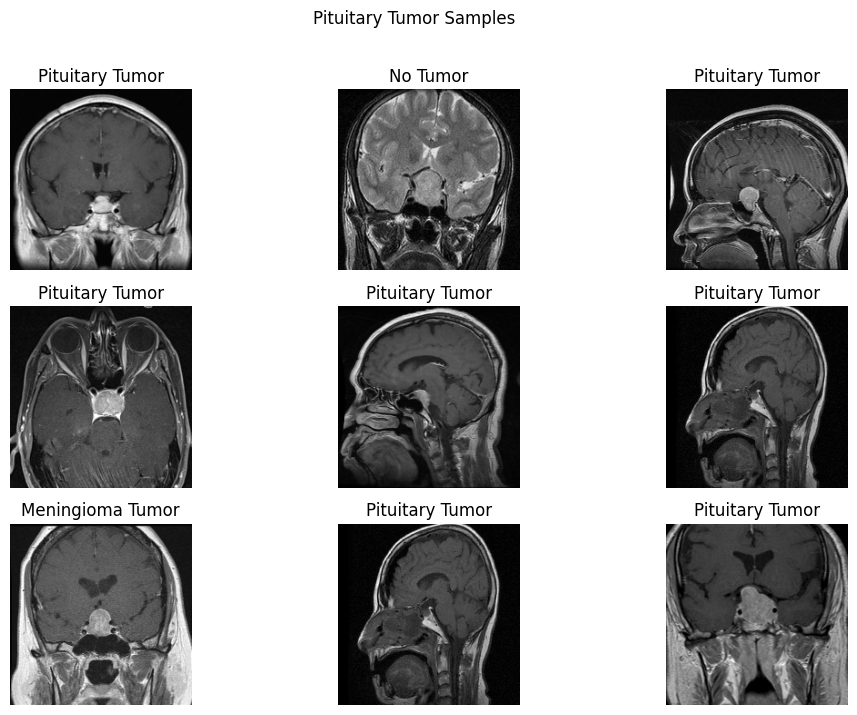

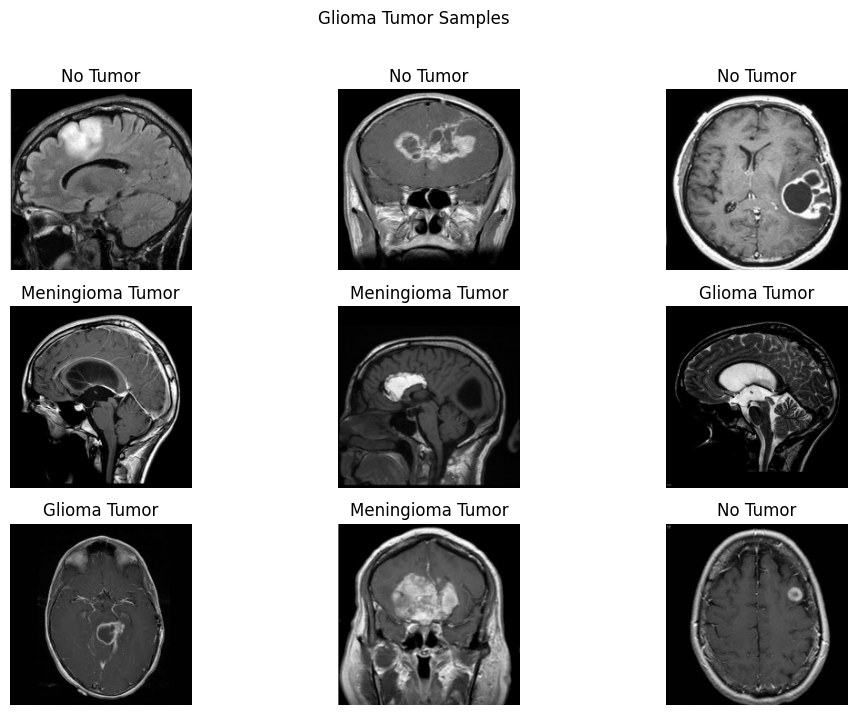

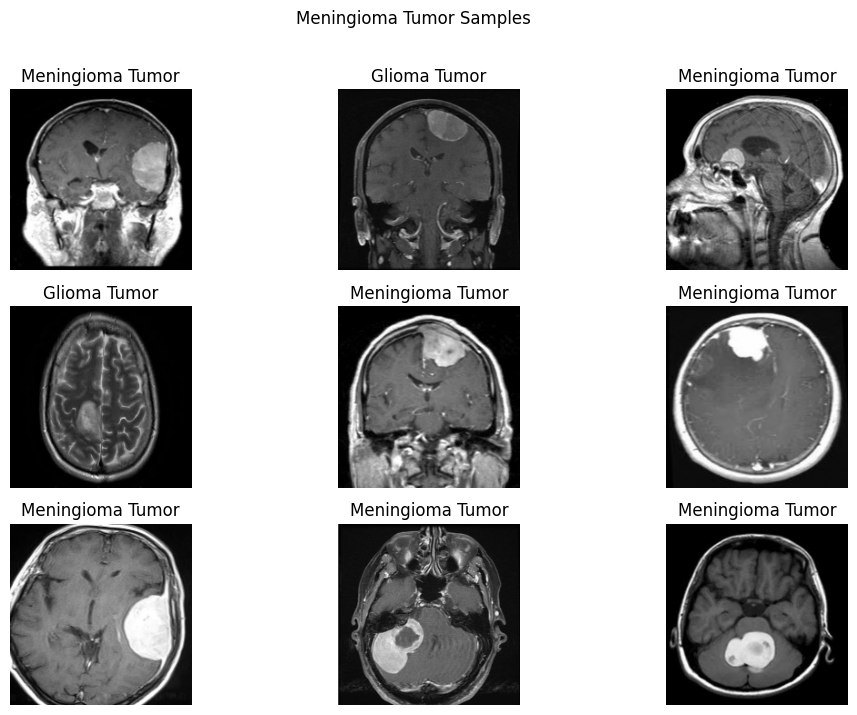

In [ ]:
# Define class labels
dec = {0: 'No Tumor', 1: 'Pituitary Tumor', 2: 'Glioma Tumor', 3: 'Meningioma Tumor'}
# Display sample images and predictions for each tumor type
tumor_folders = ['no_tumor', 'pituitary_tumor', 'glioma_tumor', 'meningioma_tumor']
for tumor_folder in tumor_folders:
    folder_path = f"/content/drive/MyDrive/Brain_Tumer/Testing/{tumor_folder}"
    title = f'{tumor_folder.replace("_", " ").title()} Samples'
    display_samples(folder_path, title)

In [ ]:
import pandas as pd

# Count the occurrences of each tumor type
tumor_counts = {dec[label]: np.sum(Y == label) for label in classes.values()}

# Create a table to represent the tumor counts
table_data = {'Index': range(1, len(classes) + 1), 'Tumor Type': list(tumor_counts.keys()), 'Count': list(tumor_counts.values())}
tumor_table = pd.DataFrame(table_data)

# Apply styling to the table to add cell borders
styled_table = tumor_table.style.set_properties(**{'border': '3px solid black', 'text-align': 'center'})

# Display the styled tumor table
print("\033[1mTumor Type Counts:\033[0m")
display(styled_table)

Tumor Type Counts:


,Index,Tumor Type,Count
0,1,No Tumor,395
1,2,Pituitary Tumor,827
2,3,Glioma Tumor,826
3,4,Meningioma Tumor,822


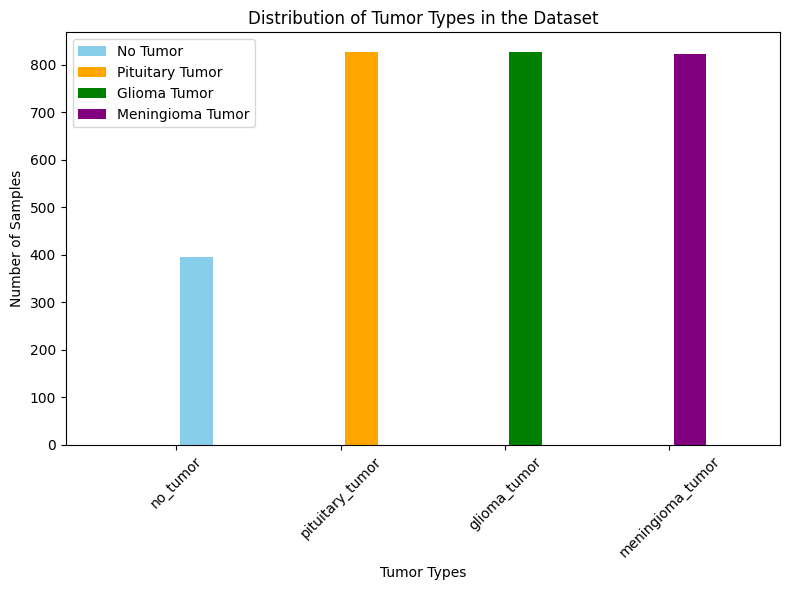

In [ ]:

# Create a histogram of tumor types with different colors
tumor_labels = [dec[label] for label in Y]
colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8, 6))
for label, color in zip(classes.values(), colors):
    plt.hist(np.array(tumor_labels)[Y == label], bins=len(classes), align='mid', rwidth=0.8, color=color, label=dec[label])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')
plt.xticks(range(len(classes)), list(classes.keys()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

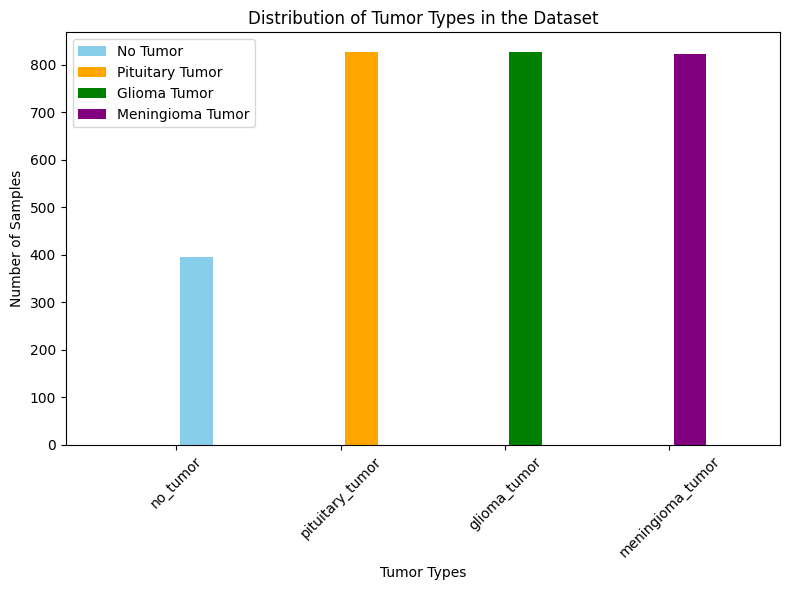

In [ ]:
# Create a histogram of tumor types with different colors
tumor_labels = [dec[label] for label in Y]
colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8, 6))
for label, color in zip(classes.values(), colors):
    plt.hist(np.array(tumor_labels)[Y == label], bins=len(classes), align='mid', rwidth=0.8, color=color, label=dec[label])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')
plt.xticks(range(len(classes)), list(classes.keys()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import SVC

# Instantiate a new Support Vector Classifier (SVC) with a linear kernel
sv_linear = SVC(kernel='linear')

# Train the sv_linear model
sv_linear.fit(pca_train, ytrain)

# Evaluate the sv_linear model's performance on the test data
test_score_linear = sv_linear.score(pca_test, ytest)
print("Test Score with Linear Kernel SVC:", test_score_linear)

Test Score with Linear Kernel SVC: 0.7926829268292683


**Reasoning**:
The subtask requires calculating accuracy, F1-score, sensitivity (recall), and specificity for the linear kernel model. I will compute these metrics using `sklearn.metrics` and store them for later comparison.



In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

# Make predictions on the test set with the linear kernel SVC
y_pred_linear = sv_linear.predict(pca_test)

# Calculate accuracy
accuracy_linear = accuracy_score(ytest, y_pred_linear)

# Calculate F1-score (macro average for multiclass)
f1_linear = f1_score(ytest, y_pred_linear, average='macro')

# Calculate sensitivity (recall) (macro average for multiclass)
recall_linear = recall_score(ytest, y_pred_linear, average='macro')

# Calculate specificity for each class and then average them
# Specificity = TN / (TN + FP)
cm_linear = confusion_matrix(ytest, y_pred_linear)
specificity_per_class = []
for i in range(len(classes)):
    # True Negative (TN): sum of all cells not in the current row or column
    tn = np.sum(np.delete(np.delete(cm_linear, i, axis=0), i, axis=1))
    # False Positive (FP): sum of the current column (excluding the diagonal)
    fp = np.sum(cm_linear[:, i]) - cm_linear[i, i]
    specificity_per_class.append(tn / (tn + fp))
specificity_linear = np.mean(specificity_per_class)

print(f"Linear Kernel SVC Metrics:")
print(f"  Accuracy: {accuracy_linear:.4f}")
print(f"  F1-Score: {f1_linear:.4f}")
print(f"  Sensitivity (Recall): {recall_linear:.4f}")
print(f"  Specificity: {specificity_linear:.4f}")

Linear Kernel SVC Metrics:
  Accuracy: 0.7927
  F1-Score: 0.7799
  Sensitivity (Recall): 0.7780
  Specificity: 0.9294


**Reasoning**:
Now I will implement the Support Vector Classifier with an RBF kernel, similar to the linear kernel. This involves instantiating the SVC model, training it, and then calculating its performance metrics on the test set.



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

# Instantiate a new Support Vector Classifier (SVC) with an RBF kernel
sv_rbf = SVC(kernel='rbf')

# Train the sv_rbf model
sv_rbf.fit(pca_train, ytrain)

# Make predictions on the test set with the RBF kernel SVC
y_pred_rbf = sv_rbf.predict(pca_test)

# Calculate accuracy
accuracy_rbf = accuracy_score(ytest, y_pred_rbf)

# Calculate F1-score (macro average for multiclass)
f1_rbf = f1_score(ytest, y_pred_rbf, average='macro')

# Calculate sensitivity (recall) (macro average for multiclass)
recall_rbf = recall_score(ytest, y_pred_rbf, average='macro')

# Calculate specificity for each class and then average them
cm_rbf = confusion_matrix(ytest, y_pred_rbf)
specificity_per_class_rbf = []
for i in range(len(classes)):
    tn_rbf = np.sum(np.delete(np.delete(cm_rbf, i, axis=0), i, axis=1))
    fp_rbf = np.sum(cm_rbf[:, i]) - cm_rbf[i, i]
    specificity_per_class_rbf.append(tn_rbf / (tn_rbf + fp_rbf))
specificity_rbf = np.mean(specificity_per_class_rbf)

print(f"RBF Kernel SVC Metrics:")
print(f"  Accuracy: {accuracy_rbf:.4f}")
print(f"  F1-Score: {f1_rbf:.4f}")
print(f"  Sensitivity (Recall): {recall_rbf:.4f}")
print(f"  Specificity: {specificity_rbf:.4f}")

RBF Kernel SVC Metrics:
  Accuracy: 0.8362
  F1-Score: 0.8316
  Sensitivity (Recall): 0.8339
  Specificity: 0.9447


**Reasoning**:
Both the linear and RBF kernel SVC models have been trained and evaluated, and their performance metrics (accuracy, F1-score, sensitivity, specificity) have been calculated and printed. The immediate subtask of implementing the RBF kernel and evaluating it is complete. I will now display a summary of the performance metrics for both kernels to allow for a direct comparison, addressing the first part of the main task which asks to 'Analyze and compare the performance'.



In [ ]:
import pandas as pd

# Create a dictionary to store the metrics for comparison
metrics_data = {
    'Metric': ['Accuracy', 'F1-Score', 'Sensitivity (Recall)', 'Specificity'],
    'Linear Kernel': [accuracy_linear, f1_linear, recall_linear, specificity_linear],
    'RBF Kernel': [accuracy_rbf, f1_rbf, recall_rbf, specificity_rbf]
}

# Create a DataFrame for better visualization
performance_df = pd.DataFrame(metrics_data)

# Display the comparison table
print("\033[1mComparison of SVC Performance (Linear vs. RBF Kernel):\033[0m")
display(performance_df.style.set_properties(**{'border': '1px solid black', 'text-align': 'center'}))

Comparison of SVC Performance (Linear vs. RBF Kernel):


,Metric,Linear Kernel,RBF Kernel
0,Accuracy,0.792683,0.836237
1,F1-Score,0.779939,0.831580
2,Sensitivity (Recall),0.778006,0.833930
3,Specificity,0.929373,0.944655


In [ ]:
from sklearn.model_selection import train_test_split

training_sizes = [0.2, 0.4, 0.6, 0.8]
linear_accuracies = []
rbf_accuracies = []

for size in training_sizes:
    # Split the original training data into a smaller subset
    xtrain_subset, _, ytrain_subset, _ = train_test_split(pca_train, ytrain, train_size=size, random_state=42, stratify=ytrain)

    # Train Linear Kernel SVC
    sv_linear_subset = SVC(kernel='linear')
    sv_linear_subset.fit(xtrain_subset, ytrain_subset)
    linear_accuracies.append(sv_linear_subset.score(pca_test, ytest))

    # Train RBF Kernel SVC
    sv_rbf_subset = SVC(kernel='rbf')
    sv_rbf_subset.fit(xtrain_subset, ytrain_subset)
    rbf_accuracies.append(sv_rbf_subset.score(pca_test, ytest))

print("Linear Kernel Accuracies for different training sizes:", linear_accuracies)
print("RBF Kernel Accuracies for different training sizes:", rbf_accuracies)

Linear Kernel Accuracies for different training sizes: [0.705574912891986, 0.7491289198606271, 0.7560975609756098, 0.7665505226480837]
RBF Kernel Accuracies for different training sizes: [0.7160278745644599, 0.7665505226480837, 0.7909407665505227, 0.8170731707317073]


**Reasoning**:
The accuracies for different training data sizes have been calculated for both linear and RBF kernels. To visualize the trends, I will plot these accuracies against the training sizes.



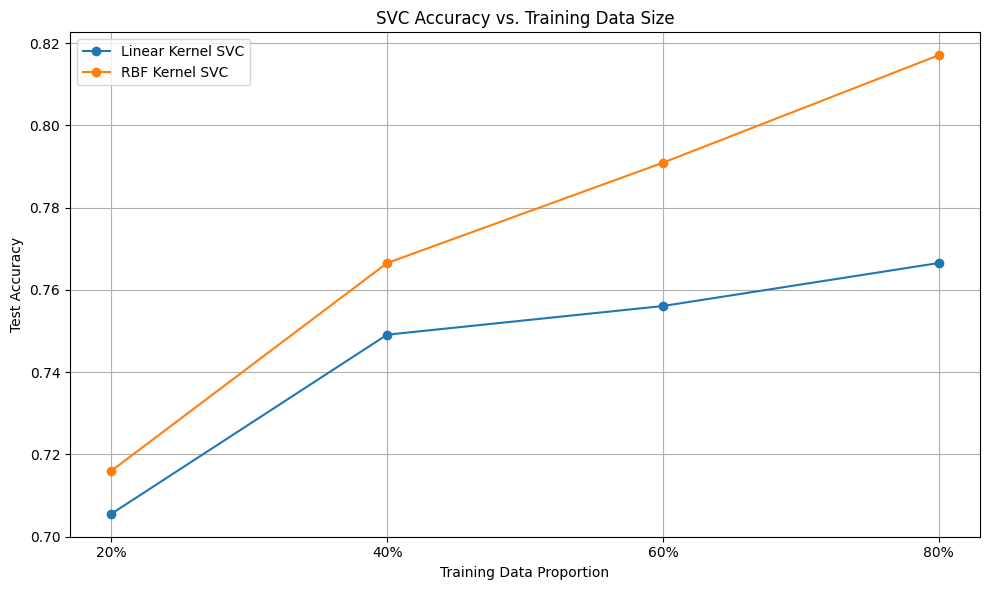

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(training_sizes, linear_accuracies, marker='o', label='Linear Kernel SVC')
plt.plot(training_sizes, rbf_accuracies, marker='o', label='RBF Kernel SVC')
plt.title('SVC Accuracy vs. Training Data Size')
plt.xlabel('Training Data Proportion')
plt.ylabel('Test Accuracy')
plt.xticks(training_sizes, [f'{int(s*100)}%' for s in training_sizes])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

# Make predictions on the training set with the linear kernel SVC
y_pred_linear_train = sv_linear.predict(pca_train)

# Calculate accuracy
accuracy_linear_train = accuracy_score(ytrain, y_pred_linear_train)

# Calculate F1-score (macro average for multiclass)
f1_linear_train = f1_score(ytrain, y_pred_linear_train, average='macro')

# Calculate sensitivity (recall) (macro average for multiclass)
recall_linear_train = recall_score(ytrain, y_pred_linear_train, average='macro')

# Calculate specificity for each class and then average them
cm_linear_train = confusion_matrix(ytrain, y_pred_linear_train)
specificity_per_class_linear_train = []
for i in range(len(classes)):
    tn = np.sum(np.delete(np.delete(cm_linear_train, i, axis=0), i, axis=1))
    fp = np.sum(cm_linear_train[:, i]) - cm_linear_train[i, i]
    specificity_per_class_linear_train.append(tn / (tn + fp))
specificity_linear_train = np.mean(specificity_per_class_linear_train)

print(f"Linear Kernel SVC Metrics (Training Data):")
print(f"  Accuracy: {accuracy_linear_train:.4f}")
print(f"  F1-Score: {f1_linear_train:.4f}")
print(f"  Sensitivity (Recall): {recall_linear_train:.4f}")
print(f"  Specificity: {specificity_linear_train:.4f}")

Linear Kernel SVC Metrics (Training Data):
  Accuracy: 1.0000
  F1-Score: 1.0000
  Sensitivity (Recall): 1.0000
  Specificity: 1.0000


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

# Make predictions on the training set with the RBF kernel SVC
y_pred_rbf_train = sv_rbf.predict(pca_train)

# Calculate accuracy
accuracy_rbf_train = accuracy_score(ytrain, y_pred_rbf_train)

# Calculate F1-score (macro average for multiclass)
f1_rbf_train = f1_score(ytrain, y_pred_rbf_train, average='macro')

# Calculate sensitivity (recall) (macro average for multiclass)
recall_rbf_train = recall_score(ytrain, y_pred_rbf_train, average='macro')

# Calculate specificity for each class and then average them
cm_rbf_train = confusion_matrix(ytrain, y_pred_rbf_train)
specificity_per_class_rbf_train = []
for i in range(len(classes)):
    tn_rbf = np.sum(np.delete(np.delete(cm_rbf_train, i, axis=0), i, axis=1))
    fp_rbf = np.sum(cm_rbf_train[:, i]) - cm_rbf_train[i, i]
    specificity_per_class_rbf_train.append(tn_rbf / (tn_rbf + fp_rbf))
specificity_rbf_train = np.mean(specificity_per_class_rbf_train)

print(f"RBF Kernel SVC Metrics (Training Data):")
print(f"  Accuracy: {accuracy_rbf_train:.4f}")
print(f"  F1-Score: {f1_rbf_train:.4f}")
print(f"  Sensitivity (Recall): {recall_rbf_train:.4f}")
print(f"  Specificity: {specificity_rbf_train:.4f}")

RBF Kernel SVC Metrics (Training Data):
  Accuracy: 0.9678
  F1-Score: 0.9684
  Sensitivity (Recall): 0.9658
  Specificity: 0.9887
